In [6]:
# Import necessary libraries for data analysis and visualization
# For data manipulation
import pandas as pd
# For numerical operations
import numpy as np
# For basic plotting
import matplotlib.pyplot as plt
# For advanced and attractive visualizations
import seaborn as sns

In [53]:
# Upload CSV/Excel file from your local system to Google Colab
from google.colab import files
uploaded = files.upload()

Saving Task-1.xlsx to Task-1.xlsx


In [54]:
# Read the dataset into a pandas DataFrame
df = pd.read_excel('Task-1.xlsx')
# Display first 5 rows to understand structure
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2.0,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2.0,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3.0,0.2,NaN
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,NaN,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,NaN,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3.0,0.2,4.8840


In [55]:

# Show dataset information
df.info()
# Show statistical summary
df.describe()
# Check for missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10193 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10192 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10192 non-null  object        
 7   Segment         10192 non-null  object        
 8   Country/Region  10193 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10192 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10193 non-null  object        
 14  Category        10193 non-null  object        
 15  Su

,0
Row ID,0
Order ID,1
Order Date,0
Ship Date,0
Ship Mode,2
Customer ID,0
Customer Name,2
Segment,2
Country/Region,1
City,0


In [56]:
# Fill numeric columns with mean
for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicate rows
df = df.drop_duplicates()

In [57]:
# Check for missing values in each column
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [58]:
# Convert 'Order Date' column to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Month and Year from date
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

In [59]:
# Find top 5 customers based on sales
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

print(top_customers)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


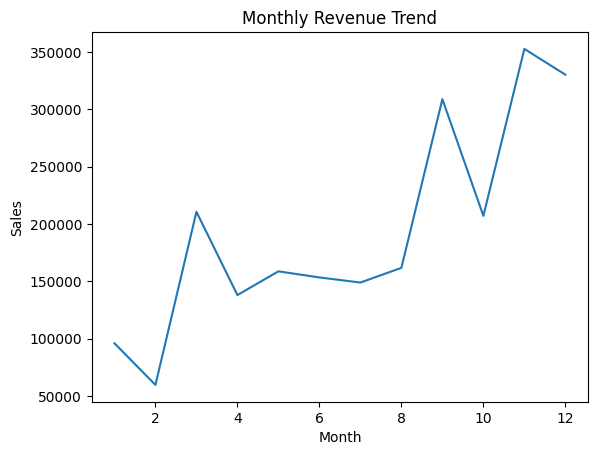

In [60]:
# Group data by Month and calculate total sales
monthly_sales = df.groupby('Month')['Sales'].sum()

# Plot line chart to visualize revenue trend
plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values)
# Add title and labels
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

# Show plot
plt.show()

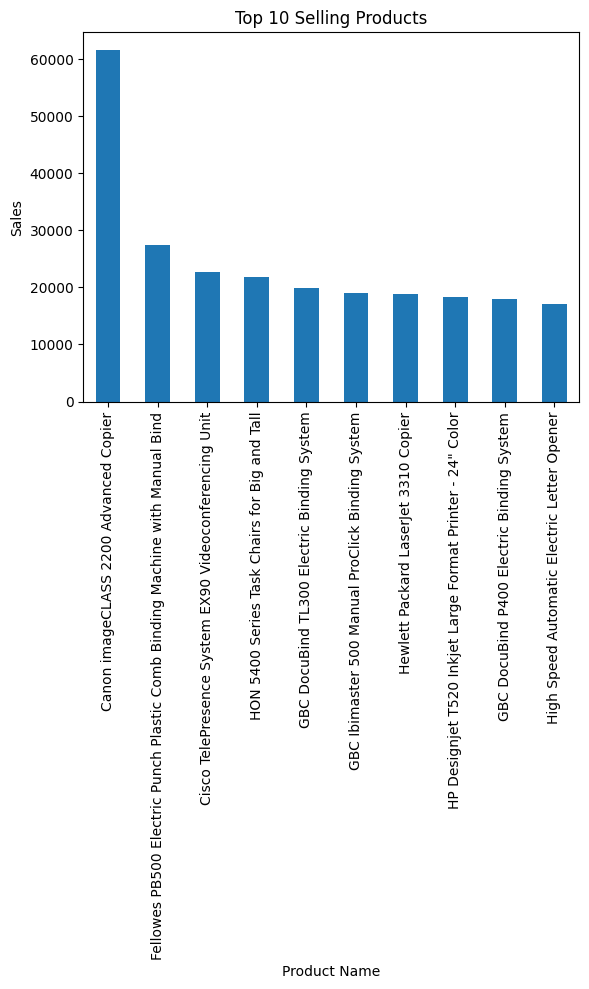

In [61]:
# Find top 10 products based on total sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# Plot bar chart
plt.figure()
top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Sales')

plt.show()

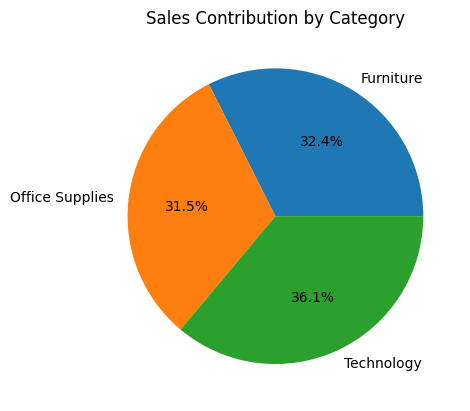

In [62]:
# Pie chart to show percentage contribution of each category
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure()
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')

plt.title('Sales Contribution by Category')

plt.show()

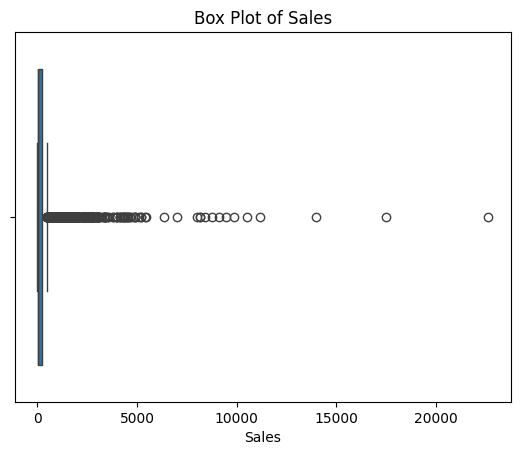

In [63]:
# Box plot to identify outliers in sales
plt.figure()
sns.boxplot(x=df['Sales'])

plt.title('Box Plot of Sales')

plt.show()

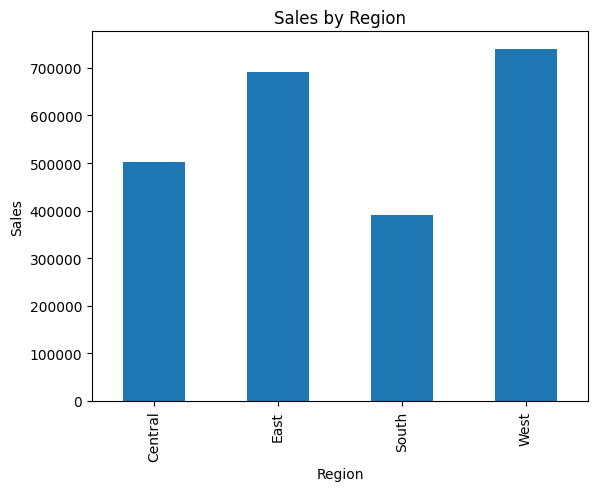

In [64]:
# Group by Region and calculate sales
region_sales = df.groupby('Region')['Sales'].sum()

# Plot bar chart
plt.figure()
region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

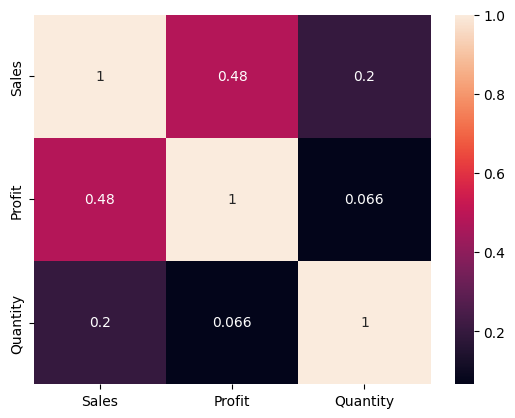

In [65]:
# Manually select columns
numeric_df = df[['Sales', 'Profit', 'Quantity']]

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

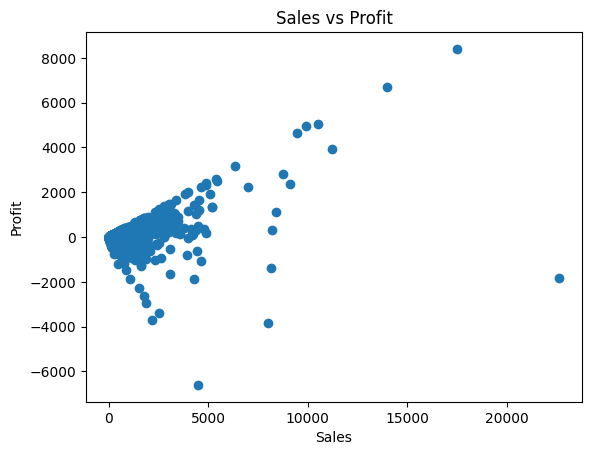

In [66]:
# Scatter plot to see relationship between Sales and Profit
plt.figure()
plt.scatter(df['Sales'], df['Profit'])

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.show()

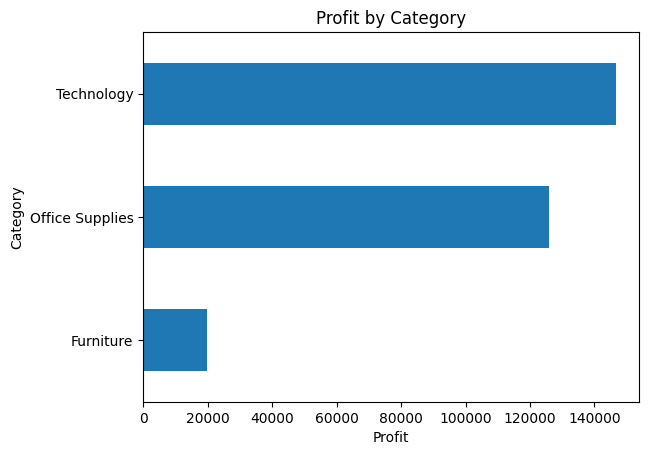

In [67]:
# Horizontal bar chart for better readability
plt.figure()
profit_by_category.sort_values().plot(kind='barh')

plt.title('Profit by Category')
plt.xlabel('Profit')
plt.ylabel('Category')

plt.show()

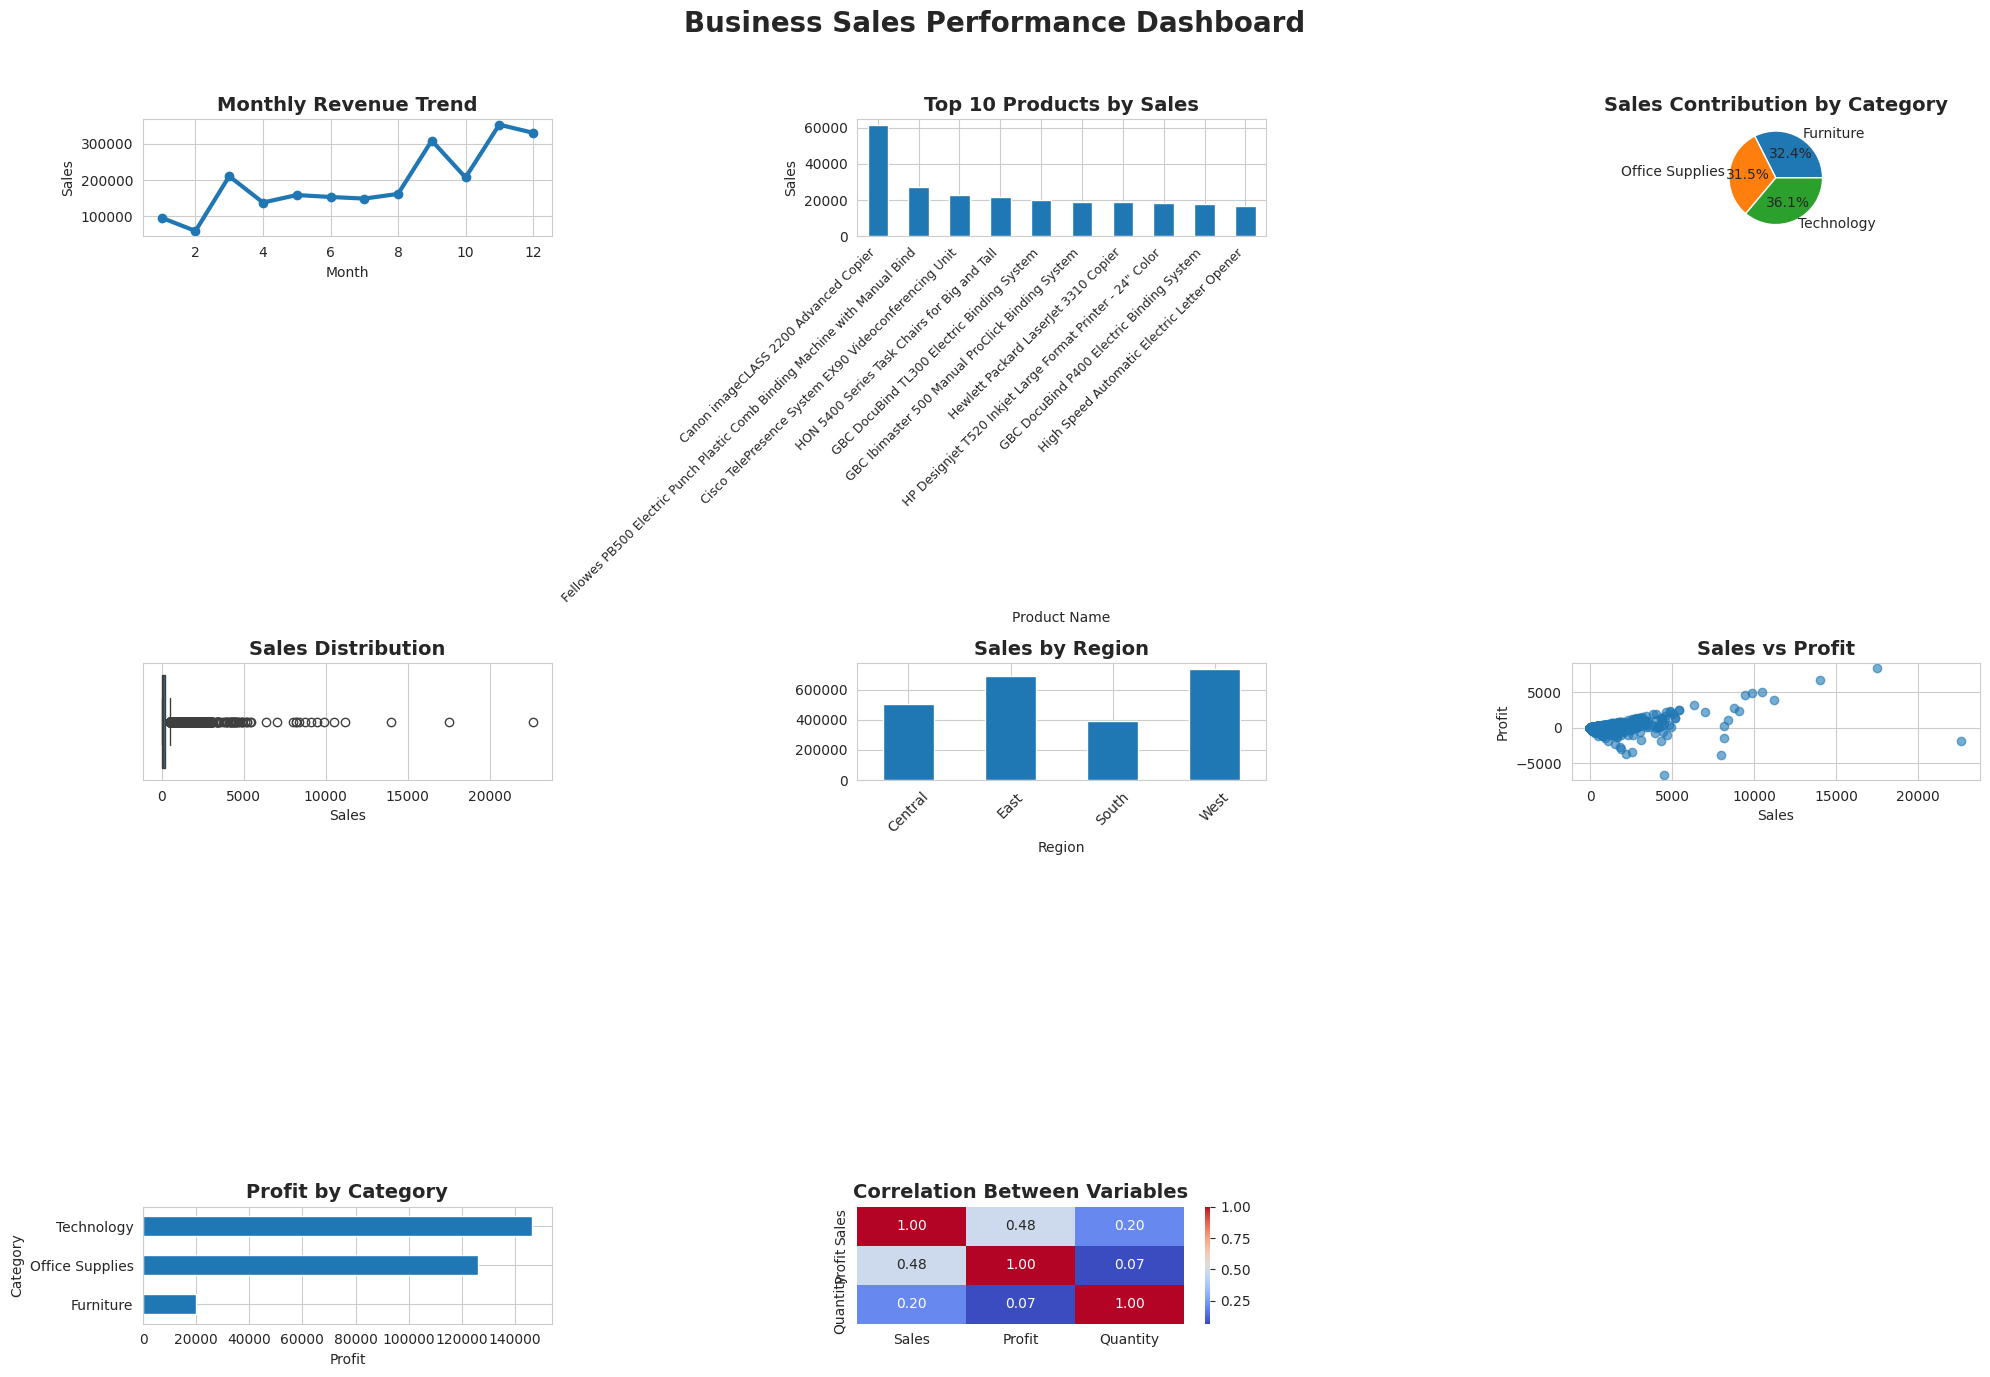

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# CLEAN STYLE (Professional Look)
# -------------------------------
sns.set_style("whitegrid")

# -------------------------------
# CREATE FIGURE
# -------------------------------
plt.figure(figsize=(20,14))

# -------------------------------
# 1. Monthly Revenue Trend
# -------------------------------
plt.subplot(3,3,1)

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.plot(monthly_sales.index, monthly_sales.values, linewidth=3, marker='o')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales')

# -------------------------------
# 2. Top Products
# -------------------------------
plt.subplot(3,3,2)

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Sales')

# -------------------------------
# 3. Category Contribution
# -------------------------------
plt.subplot(3,3,3)

category_sales = df.groupby('Category')['Sales'].sum()

plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')
plt.title('Sales Contribution by Category', fontsize=14, fontweight='bold')

# -------------------------------
# 4. Sales Distribution (Box Plot)
# -------------------------------
plt.subplot(3,3,4)

sns.boxplot(x=df['Sales'])
plt.title('Sales Distribution', fontsize=14, fontweight='bold')

# -------------------------------
# 5. Sales by Region
# -------------------------------
plt.subplot(3,3,5)

region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title('Sales by Region', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# -------------------------------
# 6. Sales vs Profit
# -------------------------------
plt.subplot(3,3,6)

plt.scatter(df['Sales'], df['Profit'], alpha=0.6)
plt.title('Sales vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Sales')
plt.ylabel('Profit')

# -------------------------------
# 7. Profit by Category
# -------------------------------
plt.subplot(3,3,7)

profit_by_category = df.groupby('Category')['Profit'].sum()

profit_by_category.sort_values().plot(kind='barh')
plt.title('Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Profit')

# -------------------------------
# 8. Correlation Heatmap
# -------------------------------
plt.subplot(3,3,8)

numeric_df = df[['Sales', 'Profit', 'Quantity']]

sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Between Variables', fontsize=14, fontweight='bold')

# -------------------------------
# MAIN TITLE (NO EMOJI → NO WARNING)
# -------------------------------
plt.suptitle('Business Sales Performance Dashboard', fontsize=20, fontweight='bold')

# -------------------------------
# PERFECT SPACING
# -------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()